# Contents 

1. [Initialisation]

# 1. Initialisation

In [23]:
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt
import qibo
from qibo import hamiltonians, set_backend, Circuit, symbols
from qibo.gates import Unitary
from qibo.symbols import *
set_backend("numpy")

[Qibo 0.2.22|INFO|2025-12-20 12:53:04]: Using numpy backend on /CPU:0


## 1.1 Define input variables
[top](#Contents) 

Choose number of qubits and Hamiltonian

In [24]:
#Number of qubits
L = 5
#Size of system
n = 2**L 
nsqrd = n**2
#Heisenberg Hamiltonian
H_def = sum([ Z(x)*Z(x+1) +X(x)*X(x+1) + Y(x)*Y(x+1)  for x in range(L-1)]) 
H_sh = hamiltonians.SymbolicHamiltonian(H_def)
H = H_sh.matrix
#minimum energy
target_energy = min(np.linalg.eigvalsh(H))
print("Target energy: ", target_energy)

[Qibo 0.2.22|WARNING|2025-12-20 12:53:04]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.


Target energy:  -7.711545013271983


## Choose initial state

In [25]:
def select_initial_state( init_type = None ):
    if init_type == "lowest energy":
        #basis vector with lowest energy
        es_ini = []
        for i in range(2**L):
            psi0 = np.zeros([1,2**L]).T
            psi0[i] = 1
            es_ini.append(H_sh.expectation(psi0.T[0]))
        min(es_ini)
        psi0 = np.zeros([1,2**L]).T
        psi0[np.argmin(es_ini)] = 1
        PSI0 = psi0 @ psi0.conj().T
        return psi0 , PSI0
    if init_type == "last":
        #last basis vector
        psi0 = np.zeros([1,2**L]).T
        psi0[-1] = 1
        PSI0 = psi0 @ psi0.conj().T
        return psi0 , PSI0
    if init_type == "first" or init_type is None:
        #first basis vector
        psi0 = np.zeros([1,2**L]).T
        psi0[0] = 1
        PSI0 = psi0 @ psi0.conj().T
        return psi0 , PSI0
    
psi0, PSI0 = select_initial_state("lowest energy") 

## 1.2 Define Maths functions

In [26]:
def dotProd(A,B):
    #HS dot product, if A,B antihermitian then this is real
    return (1/2) * np.trace(A @ (B.conj().T)).real

def commutator(A,B):
    #Implement [A,B]
    return A @ B - B @ A

def dagger(A):
    return A.conj().T

def cost_func(U):
    #E = <psi|H|psi>
    return np.trace(dagger(U) @ H @ U @ PSI0).real

def compute_moments(U):
    #Compute expected value <H>, <H^2>, and variance
    E = cost_func(U)
    S = np.trace(dagger(U) @ H @ H @ U @ PSI0).real
    return [E, S, S - E**2]
compute_moments(np.eye(n))

[np.float64(-4.0), np.float64(32.0), np.float64(16.0)]

## Define $\mu$, $\gamma$ selectors

In [27]:
def mu_line_search(U, W):
    vals = np.linspace(0, 5, 10)
    energies = [compute_moments(expm(-val * W) @ U)[0] for val in vals]
    ind = np.argmin(energies)
    return vals[ind]

def mu_poly_approx(U, W):
    return 

def mu_gamma_grid_searchA(U, R, prevW):
    num = 5
    mu_vals = np.linspace(0, 2, num)
    gamma_vals = np.linspace(-1,1,num)
    energies = [[ compute_moments(expm(-x * R -y * prevW) @ U )[0] for y in gamma_vals ] for x in mu_vals]
    ind = np.argmin(energies)
    row, col = np.unravel_index(ind, (num,num))
    return (mu_vals[row], gamma_vals[col]/mu_vals[row])

def mu_gamma_auto_PR_approx(U, W):
    return

## Define CG functions

In [28]:
def general_cg(mu_selector, mu_gamma_selector, initial_U=np.eye(n), iterations=15, tolerance=0.01):
    R = commutator(H, initial_U@PSI0@dagger(initial_U)) #Riemannian gradient
    RdotR = dotProd(R,R) #Size of gradient. If 0, U is a minimum
    print()
    print("Size of Gadient at k=0 is", RdotR)
    results = []
    mu_mins = []
    gamma_mins = [0]
    moments = compute_moments(initial_U)
    print("cost at k = 0 is", moments[0])
    results.append(moments)
    if RdotR < tolerance:
        return results
    
    #Take a SD step
    W = R #intial search direction 
    mu_min = mu_selector(initial_U, W)
    mu_mins.append(mu_min)
    U = expm(-mu_min*W)@initial_U
    moments = compute_moments(U)
    results.append(moments)

    #Take CG steps
    k=1
    prevW = W.copy() #previous search direction
    R = commutator(H, U@PSI0@dagger(U)) #new steepest descent direction
    RdotR = dotProd(R,R)
    print("Size of Gadient at k="+ str(k)+" is "+str(RdotR))
    print("cost at k=1 is", moments[0])

    while RdotR > tolerance and k < iterations:
        mu_min, gamma_min = mu_gamma_selector(U, R, prevW) #select mu and gamma
        gamma_mins.append(gamma_min)
        mu_mins.append(mu_min)
        W = R + gamma_min*prevW #CG search direction

        if dotProd(W, R) < 0: #if W not a descent direction then make W = R
            W = R
        
        U = expm(-mu_min*W) @ U
        moments = compute_moments(U)
        results.append(moments)

        prevW = W.copy() #previous search direction
        R = commutator(H, U@PSI0@dagger(U)) #new steepest descent direction
        RdotR = dotProd(R,R)
        k += 1 
        print("Cost at k="+str(k)+" is "+str(moments[0]))
        print("Size of Gadient at k="+ str(k)+ " is "+ str(RdotR))
        
    #results is [E, S, Variance] of each U, k is number of iterations, 
    # mu_mins and gamma_mins are chioices for mu, gamma at each step
    return (results, k, mu_mins, gamma_mins)

## Define Plotting Functions

/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_91109/2607000222.py:17: RuntimeWarning: divide by zero encountered in scalar divide
  return (mu_vals[row], gamma_vals[col]/mu_vals[row])
/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_91109/3684519412.py:35: RuntimeWarning: invalid value encountered in multiply
  W = R + gamma_min*prevW #CG search direction
/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_91109/2789754681.py:3: RuntimeWarning: invalid value encountered in matmul
  return (1/2) * np.trace(A @ (B.conj().T)).real
/var/folders/42/rs6w9b8x4yg3j67lsn2hxcqc0000gn/T/ipykernel_91109/3684519412.py:40: RuntimeWarning: invalid value encountered in multiply
  U = expm(-mu_min*W) @ U



Size of Gadient at k=0 is 16.0
cost at k = 0 is -4.0
Size of Gadient at k=1 is 8.087027881492482
cost at k=1 is -6.55257518609484
Cost at k=2 is -7.37536609095157
Size of Gadient at k=2 is 3.102215058551624
Cost at k=3 is -7.573310219966416
Size of Gadient at k=3 is 1.30236625196061
Cost at k=4 is nan
Size of Gadient at k=4 is nan
[[np.float64(-4.0), np.float64(32.0), np.float64(16.0)], [np.float64(-6.55257518609484), np.float64(51.02326945091828), np.float64(8.087027881492453)], [np.float64(-7.37536609095157), np.float64(57.49824003410984), np.float64(3.102215058551593)], [np.float64(-7.573310219966416), np.float64(58.657393939808394), np.float64(1.3023662519606276)], [np.float64(nan), np.float64(nan), np.float64(nan)]]
Im plotting [np.float64(-4.0), np.float64(-6.55257518609484), np.float64(-7.37536609095157), np.float64(-7.573310219966416), np.float64(nan)]


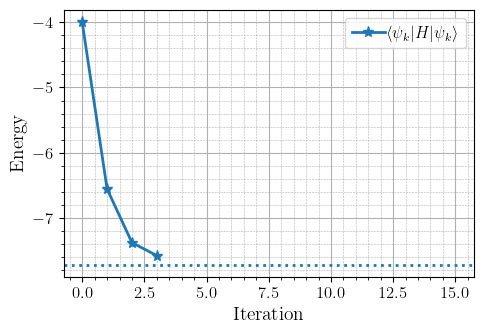

In [ ]:
def convergence_plot(results):

    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['font.size'] = 12
    plt.rcParams['savefig.dpi'] = 75
    plt.rcParams['lines.linewidth'] = 2.0
    plt.rcParams['lines.markersize'] = 8
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['legend.labelspacing'] = .3
    plt.rcParams['legend.columnspacing']= .3
    plt.rcParams['legend.handletextpad']= .1
    plt.rcParams['text.usetex'] = True
    plt.rcParams['font.family'] = "serif"
    plt.rcParams['font.serif'] = "cm"
    plt.rcParams["figure.figsize"] = [5, 3.50]
    plt.rcParams["figure.autolayout"] = True

    # for result in results:
    data = [element[0] for element in results]
    plt.plot(data, label="$\\langle \\psi_k| H | \\psi_k \\rangle$", marker='*', linestyle='-')

    plt.xlabel("Iteration")
    plt.ylabel("Energy")
    plt.grid(which='major', linewidth=0.8)
    plt.grid(which='minor', linewidth=0.4, linestyle='--')
    plt.minorticks_on()
    plt.grid(True)

    plt.legend(bbox_to_anchor=(1,1))
    plt.axline(  (0, target_energy), (15 ,target_energy), linestyle = ":" )
    
    plt.show()

def grid_plot(mus, gammas, energies):

    return

def heat_plot(mus, gammas, energies):
    return

toplot = general_cg(mu_line_search, mu_gamma_grid_searchA)[0]
convergence_plot(toplot)